<a href="https://colab.research.google.com/github/kuxx12257/machine_learnng_COOKBOOK/blob/branch1/CO2emission_linrreg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**A SIMPLE LINEAR REGRESSION MODEL THAT studies the effect of enginesze on co2 emissions in vehicles**

In [28]:
#importing the the required modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pl
%matplotlib inline
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [4]:
#downloading the dataset
!wget -O FuelConsumption.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv

--2026-02-05 08:46:10--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 72629 (71K) [text/csv]
Saving to: ‘FuelConsumption.csv’

FuelConsumption.csv 100%[===================>]  70.93K  --.-KB/s    in 0.003s  

2026-02-05 08:46:10 (21.2 MB/s) - ‘FuelConsumption.csv’ saved [72629/72629]



In [5]:
#getting familiar with the dataset
df=pd.read_csv("FuelConsumption.csv")
print(df.head(8))
print(df.describe())

   MODELYEAR   MAKE       MODEL VEHICLECLASS  ENGINESIZE  CYLINDERS  \
0       2014  ACURA         ILX      COMPACT         2.0          4   
1       2014  ACURA         ILX      COMPACT         2.4          4   
2       2014  ACURA  ILX HYBRID      COMPACT         1.5          4   
3       2014  ACURA     MDX 4WD  SUV - SMALL         3.5          6   
4       2014  ACURA     RDX AWD  SUV - SMALL         3.5          6   
5       2014  ACURA         RLX     MID-SIZE         3.5          6   
6       2014  ACURA          TL     MID-SIZE         3.5          6   
7       2014  ACURA      TL AWD     MID-SIZE         3.7          6   

  TRANSMISSION FUELTYPE  FUELCONSUMPTION_CITY  FUELCONSUMPTION_HWY  \
0          AS5        Z                   9.9                  6.7   
1           M6        Z                  11.2                  7.7   
2          AV7        Z                   6.0                  5.8   
3          AS6        Z                  12.7                  9.1   
4         

In [6]:
cdf=df[["ENGINESIZE","CO2EMISSIONS","FUELCONSUMPTION_COMB","CYLINDERS"]]
cdf.head(8)

,ENGINESIZE,CO2EMISSIONS,FUELCONSUMPTION_COMB,CYLINDERS
0,2.0,196,8.5,4
1,2.4,221,9.6,4
2,1.5,136,5.9,4
3,3.5,255,11.1,6
4,3.5,244,10.6,6
5,3.5,230,10.0,6
6,3.5,232,10.1,6
7,3.7,255,11.1,6


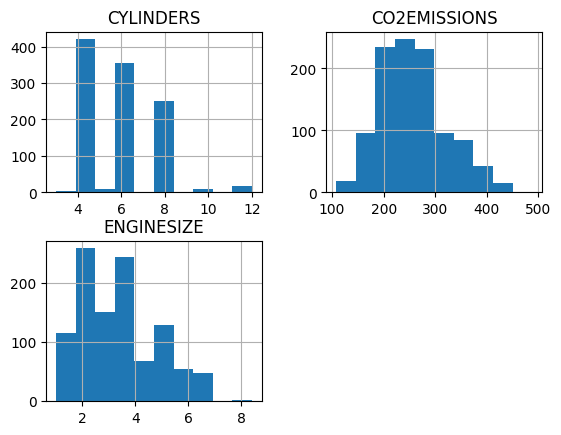

In [7]:
viz=cdf[["CYLINDERS","CO2EMISSIONS","ENGINESIZE"]]
viz.hist()
plt.show()

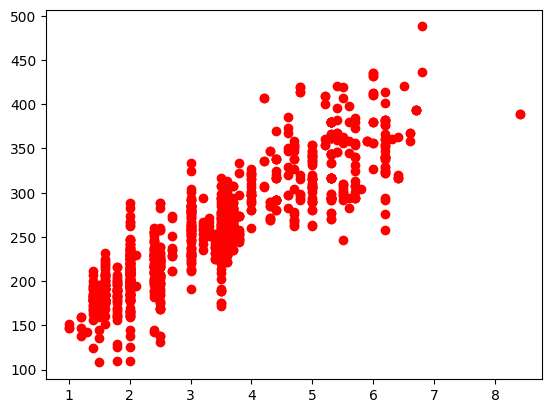

In [11]:
plt.scatter(cdf.ENGINESIZE,cdf.CO2EMISSIONS,color="red")
plt.show()

In [42]:
#splitting the daataset for trainig and testing
msk=np.random.rand(len(df))<0.85

train=cdf[msk]
test=cdf[~msk]
print(train.head())


   ENGINESIZE  CO2EMISSIONS  FUELCONSUMPTION_COMB  CYLINDERS
0         2.0           196                   8.5          4
1         2.4           221                   9.6          4
2         1.5           136                   5.9          4
3         3.5           255                  11.1          6
4         3.5           244                  10.6          6


In [43]:
print(test.head())

    ENGINESIZE  CO2EMISSIONS  FUELCONSUMPTION_COMB  CYLINDERS
5          3.5           230                  10.0          6
15         4.7           354                  15.4          8
16         4.7           338                  14.7          8
24         2.0           214                   9.3          4
33         3.0           258                  11.2          6


In [44]:
#as the sklearn models only accept the array inputs hence we need to convert our datset in array form

train_x=np.asanyarray(train[["ENGINESIZE"]])
train_y=np.asanyarray(train[["CO2EMISSIONS"]])


In [45]:

regr=linear_model.LinearRegression()
regr.fit(train_x,train_y)
print("regression coefficients:",regr.coef_)
print("regression intercept:",regr.intercept_)

regression coefficients: [[39.1397942]]
regression intercept: [125.55059986]


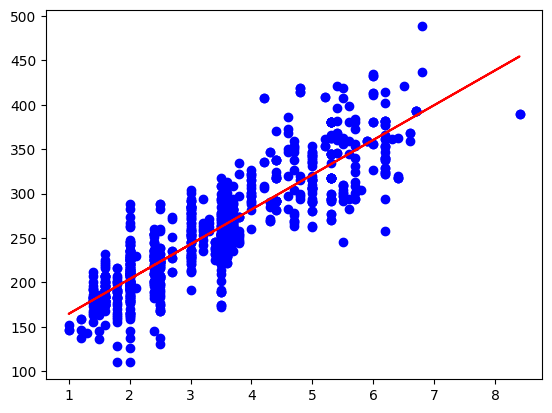

In [46]:
#VISUALISING THE
plt.scatter(train_x,train_y,color="blue")
plt.plot(train_x,regr.coef_[0][0]*train_x+regr.intercept_[0],'r')
plt.show()

In [47]:
#evaluating the model

test_x=np.asanyarray(test[["ENGINESIZE"]])
test_y=np.asanyarray(test[["CO2EMISSIONS"]])

test_Y=regr.predict(test_x)

#MEAN ABSOLUTE ERROR
print("mean absolute error:",np.mean(np.absolute(test_Y-test_y)))
print("r2 score:",r2_score(test_Y,test_y))

mean absolute error: 23.63601528411139
r2 score: 0.6167160407606209
